In [29]:
import sklearn as sk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

In [19]:
pue_hourly = pd.read_parquet('../data/pue_combined_hourly.parquet')
pue_hourly.head()

,ts,cooling_kw,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day,outdoor_air_humidity,outdoor_air_temp
0,2016-06-12 06:00:00,6.248333,4.273333,802.425833,2.371667,1.024600,6.861167,12.0,63.113333,63.530000
1,2016-06-12 07:00:00,5.743333,4.326667,804.580667,2.372167,1.024167,6.994167,12.0,59.163333,65.648333
2,2016-06-12 08:00:00,5.911667,4.286667,804.367833,2.373500,1.024283,6.980667,12.0,63.535000,64.218333
3,2016-06-12 09:00:00,5.093333,4.296667,808.211000,2.454333,1.023333,6.954667,12.0,61.041667,62.581667
4,2016-06-12 10:00:00,4.760000,4.276667,805.996167,2.374500,1.022883,7.017167,12.0,57.791667,63.075000


# Preamble

I'll be implementing a number of different methods. This will include but isn't limited to:
- Temporal train/test split (80/20 chronological)
- Log transform cooling_kw and hvac_kw
- StandardScaler fit on train, transform both
- Feature engineering: lag features, rolling 24hr mean, 
  hour of day, day of week, first differences
- ACF/PACF to justify LSTM and determine window size
- Persistence baseline model
- Random Forest feature importance check
- LSTM architecture: input → hidden layers → output
    - Architecture definition -- input size, hidden size, number of layers, dropout
    - Loss function -- MSE for regression
    - Optimizer -- Adam for learning rate
    - Training loop with validation tracking
    - Early stopping to prevent overfitting
    - Training loop with early stopping
- Evaluation: MAE, RMSE, R², MAPE vs baseline
- Visualization: predicted vs actual, residuals, loss curve
- Anomaly detection via reconstruction error

In [20]:
# Safely handles zeroes and will produce -inf
pue_hourly['hvac_kw'] = np.log1p(pue_hourly['hvac_kw']) 
pue_hourly['cooling_kw'] = np.log1p(pue_hourly['cooling_kw'])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [21]:
# Not doing train test split because the random_state parameter will randomly shuffle rows
# That doesn't work here. I cannot randomly use a row from June 2024 as training to predict a row from January 2017
# Data leakage makes poor models
# The following is a chronological split -- more appropriate for time series modelling
split_idx = int(len(pue_hourly) * 0.8)
train_df = pue_hourly.iloc[:split_idx]
test_df = pue_hourly.iloc[split_idx:]

In [22]:
feature_cols = ['cooling_kw', 'hvac_kw', 'it_power_kw', 
                           'plug_and_light_kw', 'pump_kw', 'day', 
                           'outdoor_air_humidity', 'outdoor_air_temp']

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df['pue']
y_test = test_df['pue']

print(f'Training: {train_df["ts"].min()} to {train_df["ts"].max()}')
print(f'Testing: {test_df["ts"].min()} to {test_df["ts"].max()}')

Training: 2016-06-12 06:00:00 to 2023-10-26 15:00:00
Testing: 2023-10-26 16:00:00 to 2025-08-29 18:00:00


**I explicitly kept that print statement to show I'm not incorporating data leakage here. Note, the 'ts' feature isn't included there either. That's my index, I'm using actual features for model input.**

In [23]:
# Step 3 - fit scaler on 
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape: {X_test_scaled.shape}')
print(f'Scaler means: {scaler.mean_}')

X_train_scaled shape: (64618, 8)
X_test_scaled shape: (16155, 8)
Scaler means: [   2.30312279    2.22863348 1104.93059224    3.4836214    11.370663
   15.92209283   42.26960177   54.03746353]


In [24]:
def engineer_features(df, target_col='pue', window=24):
    df = df.copy().sort_values('ts').reset_index(drop=True)
    
    # Time-based features
    df['hour'] = df['ts'].dt.hour
    df['dayofweek'] = df['ts'].dt.dayofweek
    df['month'] = df['ts'].dt.month
    
    # Lag features — recent PUE history
    for lag in [1, 2, 3, 6, 12, 24]:
        df[f'pue_lag_{lag}'] = df[target_col].shift(lag)
    
    # Rolling 24-hour mean — underlying trend
    df['pue_rolling_mean_24'] = df[target_col].rolling(window=window).mean()
    
    # Rolling standard deviation — volatility signal
    df['pue_rolling_std_24'] = df[target_col].rolling(window=window).std()
    
    # First differences — rate of change
    df['pue_diff_1'] = df[target_col].diff(1)
    df['pue_diff_24'] = df[target_col].diff(24)  # vs same hour yesterday
    
    # Same for key features
    df['it_power_lag_1'] = df['it_power_kw'].shift(1)
    df['it_power_rolling_mean_24'] = df['it_power_kw'].rolling(window=window).mean()
    df['outdoor_temp_rolling_mean_24'] = df['outdoor_air_temp'].rolling(window=window).mean()
    
    # Drop rows with NaN from lag/rolling operations
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    return df

# Apply
pue_engineered = engineer_features(pue_hourly)

print(f'Shape after feature engineering: {pue_engineered.shape}')
print(f'New features added: {pue_engineered.shape[1] - pue_hourly.shape[1]}')
print(pue_engineered.columns.tolist())

Shape after feature engineering: (71995, 26)
New features added: 16
['ts', 'cooling_kw', 'hvac_kw', 'it_power_kw', 'plug_and_light_kw', 'pue', 'pump_kw', 'day', 'outdoor_air_humidity', 'outdoor_air_temp', 'hour', 'dayofweek', 'month', 'pue_lag_1', 'pue_lag_2', 'pue_lag_3', 'pue_lag_6', 'pue_lag_12', 'pue_lag_24', 'pue_rolling_mean_24', 'pue_rolling_std_24', 'pue_diff_1', 'pue_diff_24', 'it_power_lag_1', 'it_power_rolling_mean_24', 'outdoor_temp_rolling_mean_24']


In [25]:
pue_engineered.head()

,ts,cooling_kw,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day,outdoor_air_humidity,outdoor_air_temp,...,pue_lag_6,pue_lag_12,pue_lag_24,pue_rolling_mean_24,pue_rolling_std_24,pue_diff_1,pue_diff_24,it_power_lag_1,it_power_rolling_mean_24,outdoor_temp_rolling_mean_24
0,2016-06-13 06:00:00,1.759114,1.661290,730.368644,2.375085,1.025288,6.950508,13.0,64.715254,62.588136,...,1.026083,1.029567,1.024600,1.026480,0.002299,-0.000179,0.000688,729.268167,748.546881,72.039714
1,2016-06-13 07:00:00,1.762731,1.668336,730.409667,2.465333,1.025417,6.939667,13.0,64.645000,62.618333,...,1.026833,1.029500,1.024167,1.026532,0.002258,0.000129,0.001250,730.368644,745.456423,71.913464
2,2016-06-13 08:00:00,1.795641,1.662663,726.663667,2.378667,1.025667,7.048167,13.0,70.993333,60.945000,...,1.027050,1.029083,1.024283,1.026590,0.002215,0.000250,0.001383,730.409667,742.218749,71.777075
3,2016-06-13 09:00:00,1.781990,1.659180,728.300500,2.375667,1.025500,6.971333,13.0,75.076667,59.223333,...,1.025750,1.029833,1.023333,1.026680,0.002119,-0.000167,0.002167,726.663667,738.889145,71.637145
4,2016-06-13 10:00:00,1.699909,1.623477,725.054483,2.373793,1.024741,7.090690,13.0,75.134483,58.591379,...,1.025833,1.028750,1.022883,1.026757,0.002005,-0.000759,0.001858,728.300500,735.516575,71.450327


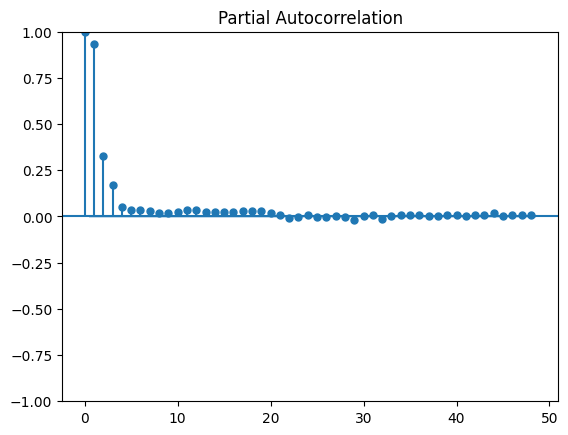

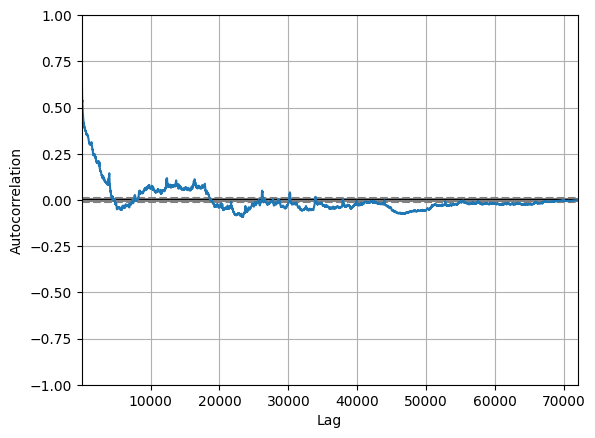

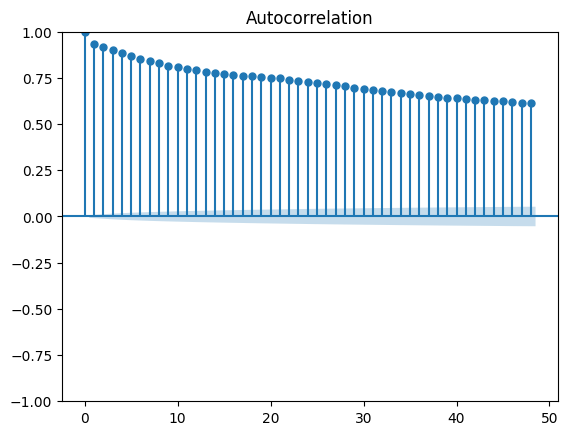

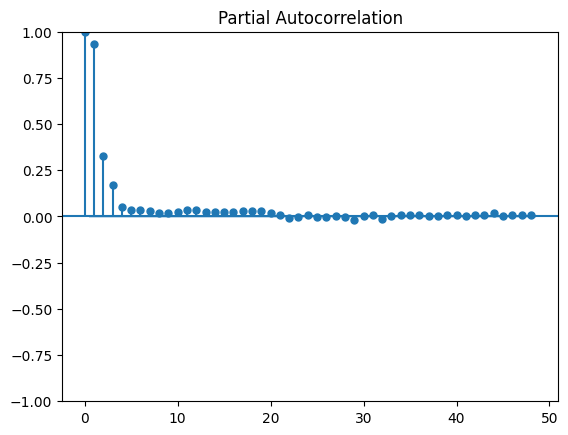

In [40]:
autocorrelation_plot(pue_engineered['pue'])
plot_acf(pue_engineered['pue'], lags=48) # 2 day window span to ID if patterns exist or not
plot_pacf(pue_engineered['pue'], lags=48) # What lag order does PACF suggest

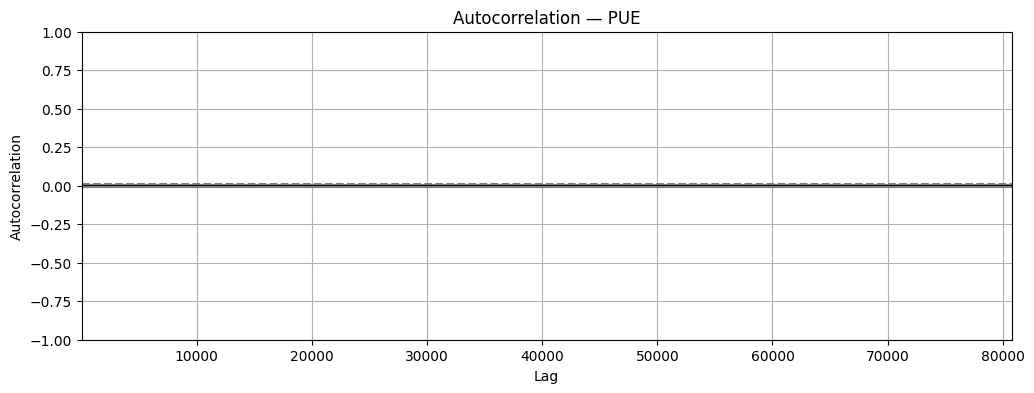

In [34]:
# General autocorrelation overview
plt.figure(figsize=(12, 4))
autocorrelation_plot(pue_hourly['pue'])
plt.title('Autocorrelation — PUE')
plt.savefig('../assets/autocorrelation_overview.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

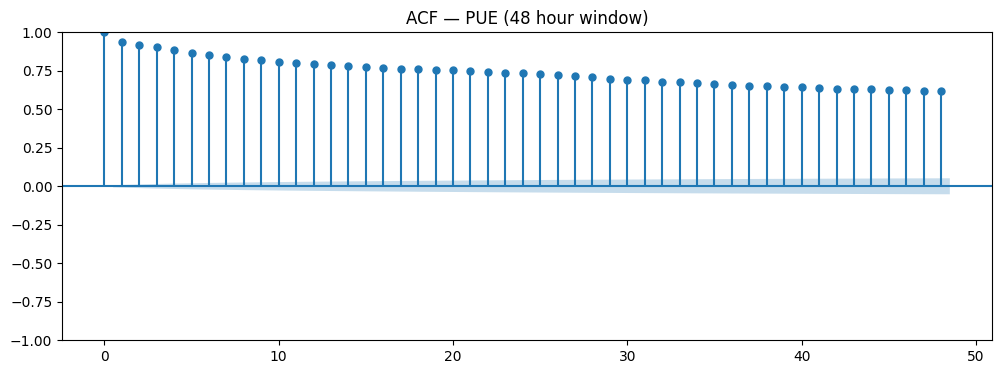

In [35]:
# ACF — how far back does correlation persist?
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(pue_hourly['pue'].dropna(), lags=48, ax=ax)
ax.set_title('ACF — PUE (48 hour window)')
plt.savefig('../assets/acf_pue.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

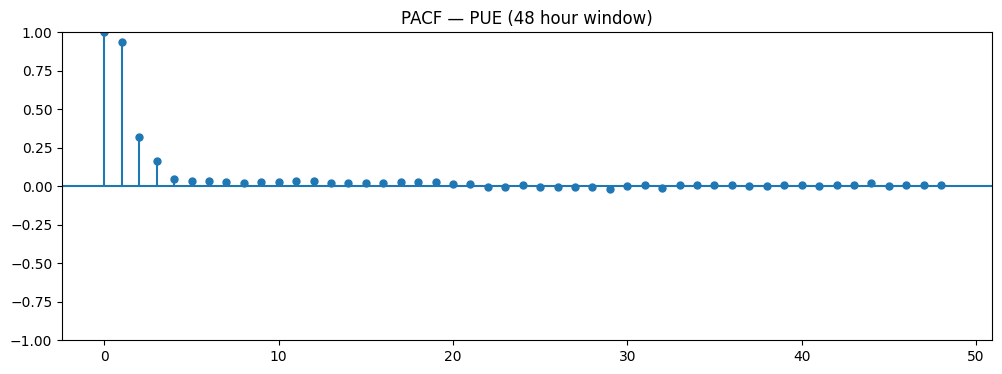

In [36]:
# PACF — direct lag contribution after removing intermediate effects
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(pue_hourly['pue'].dropna(), lags=48, ax=ax)
ax.set_title('PACF — PUE (48 hour window)')
plt.savefig('../assets/pacf_pue.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

### Persistence Baseline

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Persistence model — predict next hour = current hour
# Align on test set only
y_test_clean = y_test.dropna()
y_test_vals = y_test_clean.values[1:]           # actual values from t+1 onward
persistence_preds = y_test_clean.values[:-1]    # predict using t to forecast t+1

mae_baseline = mean_absolute_error(y_test_vals, persistence_preds)
rmse_baseline = np.sqrt(mean_squared_error(y_test_vals, persistence_preds))
r2_baseline = r2_score(y_test_vals, persistence_preds)
mape_baseline = np.mean(np.abs((y_test_vals - persistence_preds) / y_test_vals)) * 100

print("=== Persistence Baseline ===")
print(f"MAE:  {mae_baseline:.4f} PUE units")
print(f"RMSE: {rmse_baseline:.4f} PUE units")
print(f"R²:   {r2_baseline:.4f}")
print(f"MAPE: {mape_baseline:.2f}%")

=== Persistence Baseline ===
MAE:  0.0015 PUE units
RMSE: 0.0070 PUE units
R²:   0.9742
MAPE: 0.13%


### Random Forest Regressor (Feature Importance)

                     feature  importance
                   pue_lag_1    0.787235
                  pue_diff_1    0.091068
                 pue_diff_24    0.070450
         pue_rolling_mean_24    0.022696
                  cooling_kw    0.008851
                     hvac_kw    0.006430
                     pump_kw    0.004121
                 it_power_kw    0.003056
                   pue_lag_2    0.001242
                   pue_lag_3    0.001121
outdoor_temp_rolling_mean_24    0.000622
              it_power_lag_1    0.000616
                        hour    0.000562
    it_power_rolling_mean_24    0.000542
          pue_rolling_std_24    0.000268
           plug_and_light_kw    0.000213
                  pue_lag_24    0.000174
        outdoor_air_humidity    0.000154
                         day    0.000141
            outdoor_air_temp    0.000118
                   pue_lag_6    0.000094
                  pue_lag_12    0.000091
                   dayofweek    0.000070
                

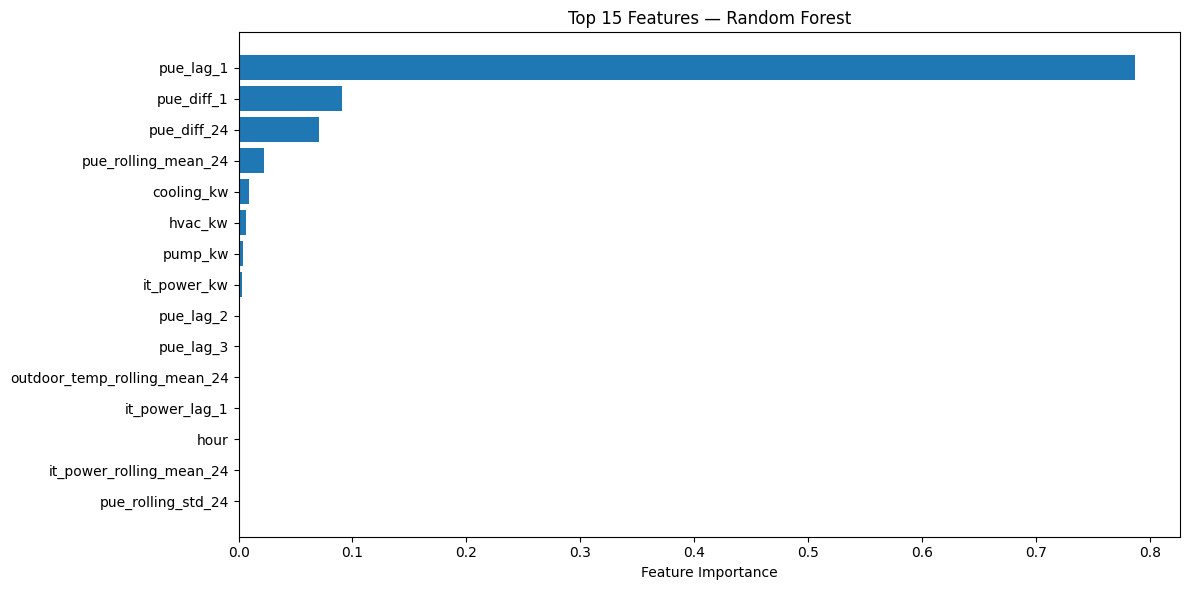

In [44]:
# Random Forest Feature Importance
from sklearn.ensemble import RandomForestRegressor

feature_cols = [col for col in pue_engineered.columns 
                if col not in ['ts', 'pue']]

X_rf = pue_engineered[feature_cols]
y_rf = pue_engineered['pue']

# Temporal split on engineered dataframe
split_idx = int(len(pue_engineered) * 0.8)
X_rf_train = X_rf.iloc[:split_idx]
y_rf_train = y_rf.iloc[:split_idx]

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_rf_train, y_rf_train)

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.to_string(index=False))

# Plot
plt.figure(figsize=(12, 6))
plt.barh(importance_df['feature'][:15], 
         importance_df['importance'][:15])
plt.xlabel('Feature Importance')
plt.title('Top 15 Features — Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../assets/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

### Long Short-Term Memory Neural Network

In [45]:
# ── Sequence construction ─────────────────────────────────────────────────────
def create_sequences(X, y, window_size=24):
    """Convert flat dataframe into overlapping LSTM windows."""
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i + window_size])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)

# ── Feature prep ──────────────────────────────────────────────────────────────
feature_cols = [col for col in pue_engineered.columns 
                if col not in ['ts', 'pue']]

split_idx = int(len(pue_engineered) * 0.8)
train_df = pue_engineered.iloc[:split_idx]
test_df  = pue_engineered.iloc[split_idx:]

X_train = train_df[feature_cols].values
X_test  = test_df[feature_cols].values
y_train = train_df['pue'].values
y_test  = test_df['pue'].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

WINDOW = 24
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, WINDOW)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test,  WINDOW)

print(f'X_train_seq shape: {X_train_seq.shape}')  # (samples, 24, n_features)
print(f'X_test_seq shape:  {X_test_seq.shape}')

X_train_seq shape: (57572, 24, 24)
X_test_seq shape:  (14375, 24, 24)


In [46]:
# ── Model definition ──────────────────────────────────────────────────────────
class PUEForecastLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(PUEForecastLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])  # last timestep only
        return out.squeeze()

input_size = X_train_seq.shape[2]  # number of features
model = PUEForecastLSTM(input_size=input_size)
print(model)

PUEForecastLSTM(
  (lstm): LSTM(24, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [48]:
# ── Training loop ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {device}')

model = model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

X_train_tensor = torch.FloatTensor(X_train_seq).to(device)
y_train_tensor = torch.FloatTensor(y_train_seq).to(device)
X_test_tensor  = torch.FloatTensor(X_test_seq).to(device)
y_test_tensor  = torch.FloatTensor(y_test_seq).to(device)

EPOCHS = 50
BATCH_SIZE = 64
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    permutation = torch.randperm(X_train_tensor.size(0))
    epoch_loss = 0

    for i in range(0, X_train_tensor.size(0), BATCH_SIZE):
        indices = permutation[i:i + BATCH_SIZE]
        batch_X = X_train_tensor[indices]
        batch_y = y_train_tensor[indices]

        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Validation loss
    model.eval()
    with torch.no_grad():
        val_output = model(X_test_tensor)
        val_loss = criterion(val_output, y_test_tensor).item()

    train_losses.append(epoch_loss / (len(X_train_tensor) / BATCH_SIZE))
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_losses[-1]:.6f} | Val Loss: {val_loss:.6f}')

Training on: cpu
Epoch 10/50 | Train Loss: 0.000034 | Val Loss: 0.000672
Epoch 20/50 | Train Loss: 0.000055 | Val Loss: 0.001180
Epoch 30/50 | Train Loss: 0.000042 | Val Loss: 0.002393
Epoch 40/50 | Train Loss: 0.000046 | Val Loss: 0.000460
Epoch 50/50 | Train Loss: 0.000018 | Val Loss: 0.003184


In [49]:
# ── Evaluation ────────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).cpu().numpy()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test_seq, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred))
r2   = r2_score(y_test_seq, y_pred)
mape = np.mean(np.abs((y_test_seq - y_pred) / y_test_seq)) * 100

print("\n=== LSTM Results ===")
print(f"MAE:  {mae:.4f} PUE units")
print(f"RMSE: {rmse:.4f} PUE units")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"\nBaseline MAE: {mae_baseline:.4f}")
print(f"LSTM MAE:     {mae:.4f}")
print(f"Improvement:  {((mae_baseline - mae) / mae_baseline * 100):.1f}%")


=== LSTM Results ===
MAE:  0.0291 PUE units
RMSE: 0.0564 PUE units
R²:   -0.6066
MAPE: 2.66%

Baseline MAE: 0.0015
LSTM MAE:     0.0291
Improvement:  -1908.5%


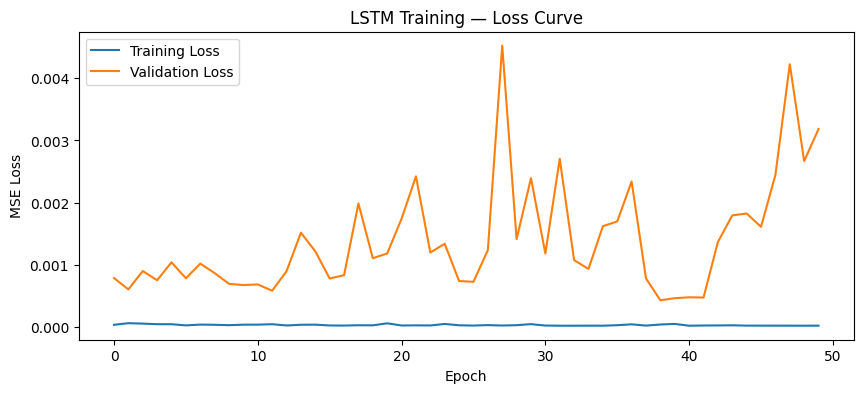

In [50]:
# ── Loss curve plot ───────────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('LSTM Training — Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.savefig('../assets/lstm_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

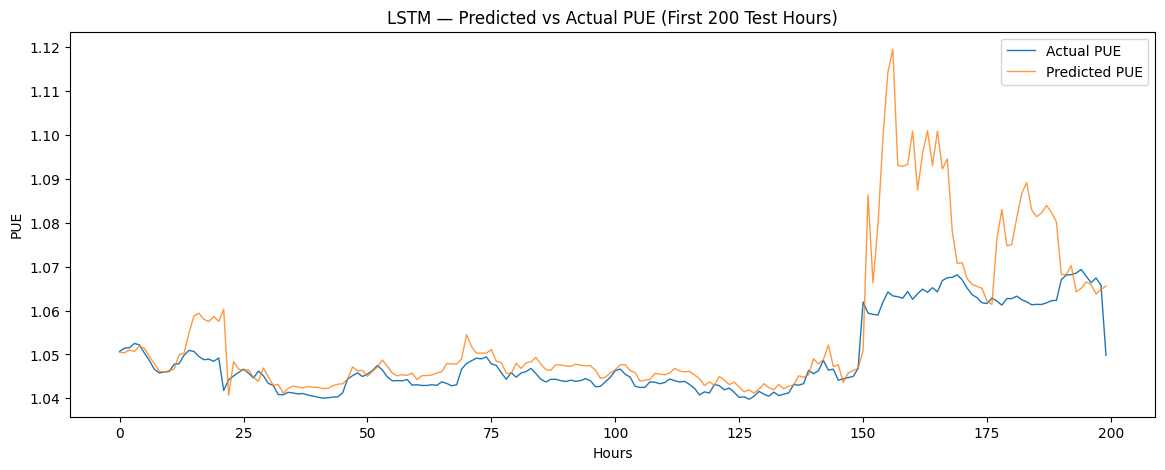

In [51]:
# ── Predicted vs actual ───────────────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(y_test_seq[:200], label='Actual PUE', linewidth=1)
plt.plot(y_pred[:200], label='Predicted PUE', linewidth=1, alpha=0.8)
plt.title('LSTM — Predicted vs Actual PUE (First 200 Test Hours)')
plt.xlabel('Hours')
plt.ylabel('PUE')
plt.legend()
plt.savefig('../assets/lstm_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()